<a href="https://colab.research.google.com/github/stefs2/COSC325-Final-Project/blob/main/Neural-Network/nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

print("Libraries loaded")

Libraries loaded


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/stefs2/COSC325-Final-Project/main/housing-data/train.csv')
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Separate target and drop ID
df['SalePrice'] = np.log1p(df['SalePrice'])
y = df['SalePrice'].values
df = df.drop(columns=['SalePrice', 'Id'])

# Fill NaN that means absence of feature
none_cols = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
             'GarageType','GarageFinish','GarageQual','GarageCond',
             'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1',
             'BsmtFinType2','MasVnrType']
for col in none_cols:
    if col in df.columns:
        df[col] = df[col].fillna('None')

# LotFrontage fill with median
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

# Feature engineering: combine square footage into one metric
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# Feature engineering: total bathrooms
df['TotalBath'] = (df['FullBath'] + df['HalfBath'] * 0.5 +
                   df['BsmtFullBath'] + df['BsmtHalfBath'] * 0.5)

# Feature engineering: house age and remodel age
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

# Log transform skewed numeric features
skewed_cols = ['LotArea', 'TotalSF', 'GrLivArea', 'TotalBsmtSF']
for col in skewed_cols:
    if col in df.columns:
        df[col] = np.log1p(df[col])

# Fill remaining NaN
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('None')
    else:
        df[col] = df[col].fillna(0)

# One-hot encode categorical columns
df = pd.get_dummies(df)

print(f"Shape: {df.shape}")
print(f"Any NaN: {df.isnull().any().any()}")

Shape: (1460, 307)
Any NaN: False


## Train/Validation Split and Scaling
Splits data 80/20 into training and validation sets. StandardScaler normalizes features, which is important for neural networks since they are sensitive to feature scale.

In [4]:
X = df.values.astype(np.float32)
y = y.astype(np.float32)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

print(f"Train size: {X_train.shape}")
print(f"Val size: {X_val.shape}")

Train size: (1168, 307)
Val size: (292, 307)


## PyTorch DataLoaders
Converts arrays to PyTorch tensors and wraps them in DataLoaders for batch training.

In [5]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print("DataLoaders ready")

DataLoaders ready


## MLP Model Definition
Defines a 4-layer neural network. Each layer reduces dimensionality and learns patterns in the data. Dropout layers prevent overfitting. The final layer outputs a single value, the predicted log sale price.

In [6]:
class HousingMLP(nn.Module):
    def __init__(self, input_dim):
        super(HousingMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),  # normalizes activations for stable training
            nn.ReLU(),
            nn.Dropout(0.3),      # randomly drops neurons to prevent overfitting
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),  # normalizes activations for stable training
            nn.ReLU(),
            nn.Dropout(0.3),      # randomly drops neurons to prevent overfitting
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)      # single output: predicted log sale price
        )

    def forward(self, x):
        return self.network(x)

input_dim = X_train.shape[1]
model = HousingMLP(input_dim)
print(model)
print(f"\nInput features: {input_dim}")

HousingMLP(
  (network): Sequential(
    (0): Linear(in_features=307, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=1, bias=True)
  )
)

Input features: 307


## Training
Trains the model over 200 epochs. Uses MSE as the loss function, Adam as the optimizer, and a learning rate scheduler that reduces the learning rate every 50 epochs.

In [7]:
# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)  # weight decay adds L2 regularization
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)
NUM_EPOCHS = 1000
train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):
    # Training pass
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()       # clear gradients from previous step
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()             # compute gradients
        optimizer.step()            # update weights
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    # Validation pass
    model.eval()
    with torch.no_grad():           # no gradient tracking needed for validation
        val_batch_losses = []
        for X_batch, y_batch in val_loader:
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            val_batch_losses.append(loss.item())
        val_losses.append(np.mean(val_batch_losses))

    # Adjusts learning rate when validation loss stops improving
    scheduler.step(val_losses[-1])

    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

print("\nTraining complete!")

Epoch 200/1000 | Train Loss: 0.1108 | Val Loss: 0.0825
Epoch 400/1000 | Train Loss: 0.0160 | Val Loss: 0.0235
Epoch 600/1000 | Train Loss: 0.0091 | Val Loss: 0.0174
Epoch 800/1000 | Train Loss: 0.0093 | Val Loss: 0.0173
Epoch 1000/1000 | Train Loss: 0.0098 | Val Loss: 0.0170

Training complete!


## Evaluation
Converts predictions back from log scale to actual dollar values, then computes RMSE and R-squared to compare against other models.

In [8]:
model.eval()
with torch.no_grad():
    # Get predictions on validation set
    y_pred_log = model(X_val_t).squeeze().numpy()
    y_true_log = y_val_t.squeeze().numpy()

# Convert from log scale back to actual dollars
y_pred_actual = np.expm1(y_pred_log)
y_true_actual = np.expm1(y_true_log)

# Compute metrics
rmse = np.sqrt(np.mean((y_pred_actual - y_true_actual) ** 2))
r2 = r2_score(y_true_actual, y_pred_actual)

print(f"RMSE:      {rmse:.2f}")
print(f"R-squared: {r2:.4f}")

RMSE:      29129.18
R-squared: 0.8894


## Training Curve
Plots training and validation loss over epochs to visualize how the model learned over time.

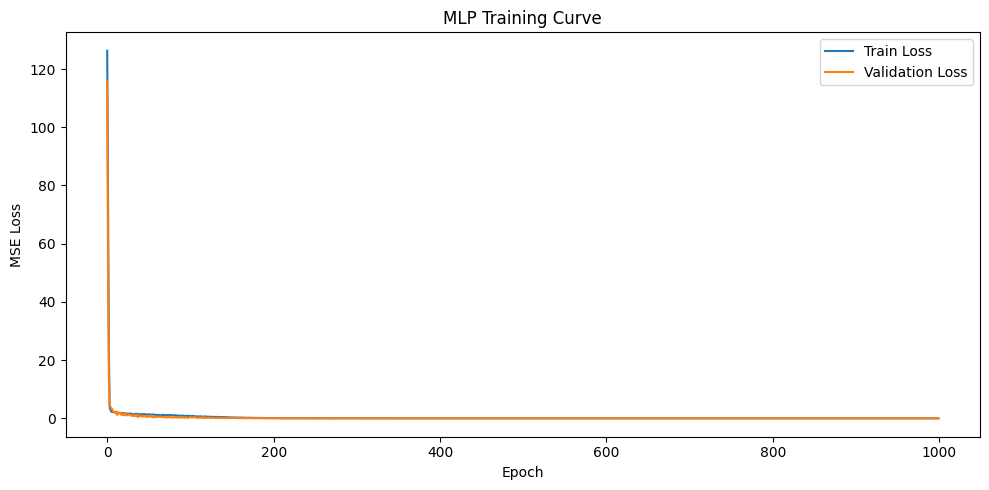

Saved: mlp_training_curve.png


In [9]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('MLP Training Curve')
plt.legend()
plt.tight_layout()
plt.savefig('mlp_training_curve.png', dpi=150)
plt.show()
print("Saved: mlp_training_curve.png")

## Predicted vs Actual
Plots predicted sale prices against actual sale prices. Points closer to the red diagonal line indicate more accurate predictions.

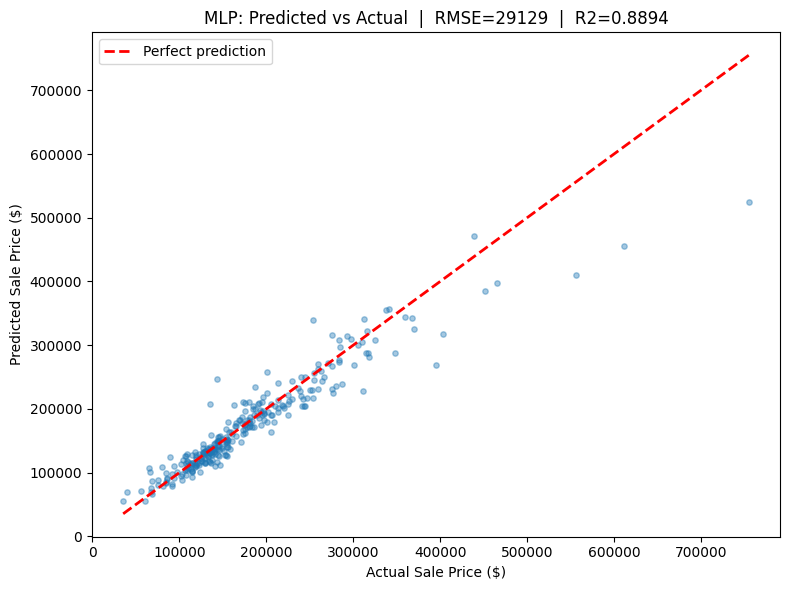

Saved: mlp_predicted_vs_actual.png


In [10]:
plt.figure(figsize=(8, 6))  # set figure size
plt.scatter(y_true_actual, y_pred_actual, alpha=0.4, s=15)  # plot each prediction as a dot
plt.plot([y_true_actual.min(), y_true_actual.max()],
         [y_true_actual.min(), y_true_actual.max()],
         'r--', lw=2, label='Perfect prediction')  # diagonal line represents perfect predictions
plt.xlabel('Actual Sale Price ($)')   # x axis is the true price
plt.ylabel('Predicted Sale Price ($)')  # y axis is what the model predicted
plt.title(f'MLP: Predicted vs Actual  |  RMSE={rmse:.0f}  |  R2={r2:.4f}')  # include metrics in title
plt.legend()
plt.tight_layout()
plt.savefig('mlp_predicted_vs_actual.png', dpi=150)  # save for the report
plt.show()
print("Saved: mlp_predicted_vs_actual.png")

## Real World Prediction Example
Loads the test set, runs it through the same preprocessing pipeline, and predicts sale prices for unseen houses.

In [11]:
# Load the test set from the repo
df_test = pd.read_csv('https://raw.githubusercontent.com/stefs2/COSC325-Final-Project/main/housing-data/test.csv')

# Save IDs for reference later
test_ids = df_test['Id'].values

# Drop ID column
df_test = df_test.drop(columns=['Id'])

# Fill absence features with None
for col in none_cols:
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna('None')

# LotFrontage fill with median
df_test['LotFrontage'] = df_test['LotFrontage'].fillna(df_test['LotFrontage'].median())

# Feature engineering: same as training
df_test['TotalSF'] = df_test['TotalBsmtSF'] + df_test['1stFlrSF'] + df_test['2ndFlrSF']
df_test['TotalBath'] = (df_test['FullBath'] + df_test['HalfBath'] * 0.5 +
                        df_test['BsmtFullBath'] + df_test['BsmtHalfBath'] * 0.5)
df_test['HouseAge'] = df_test['YrSold'] - df_test['YearBuilt']
df_test['RemodAge'] = df_test['YrSold'] - df_test['YearRemodAdd']

# Log transform skewed features
for col in skewed_cols:
    if col in df_test.columns:
        df_test[col] = np.log1p(df_test[col])

# Fill remaining NaN
for col in df_test.columns:
    if df_test[col].dtype == 'object':
        df_test[col] = df_test[col].fillna('None')
    else:
        df_test[col] = df_test[col].fillna(0)

# One-hot encode
df_test = pd.get_dummies(df_test)

# Align test columns to match training columns
df_test = df_test.reindex(columns=df.columns, fill_value=0)

print(f"Test set shape: {df_test.shape}")

Test set shape: (1459, 307)


In [13]:
# Scale test data using the same scaler fitted on training data
X_test = df_test.values.astype(np.float32)
X_test_scaled = scaler.transform(X_test)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

# Run model on test set
model.eval()
with torch.no_grad():
    y_test_pred_log = model(X_test_t).squeeze().numpy()  # predictions in log scale

# Convert back to actual dollars
y_test_pred_actual = np.expm1(y_test_pred_log)

print(f"Predictions generated for {len(y_test_pred_actual)} houses")
print(f"Predicted price range: ${y_test_pred_actual.min():,.0f} to ${y_test_pred_actual.max():,.0f}")

Predictions generated for 1459 houses
Predicted price range: $47,084 to $587,769


## Demo: Predicting a Single House
Selects one house from the test set and shows its key features alongside the model's predicted sale price. This is the real world application of the model.

In [14]:
# Pick a specific house to highlight as the demo example
house_idx = 0  # first house in the test set
house_id = test_ids[house_idx]
predicted_price = y_test_pred_actual[house_idx]

# Pull the original raw features for display
df_test_raw = pd.read_csv('https://raw.githubusercontent.com/stefs2/COSC325-Final-Project/main/housing-data/test.csv')
house = df_test_raw.iloc[house_idx]

print(f"House ID: {house_id}")
print(f"Neighborhood: {house['Neighborhood']}")
print(f"Year Built: {house['YearBuilt']}")
print(f"Overall Quality (1-10): {house['OverallQual']}")
print(f"Above Ground Living Area: {house['GrLivArea']} sq ft")
print(f"Total Basement SF: {house['TotalBsmtSF']} sq ft")
print(f"Full Bathrooms: {house['FullBath']}")
print(f"Bedrooms: {house['BedroomAbvGr']}")
print(f"Garage Capacity: {house['GarageCars']} cars")
print(f"\nMLP Predicted Sale Price: ${predicted_price:,.0f}")

House ID: 1461
Neighborhood: NAmes
Year Built: 1961
Overall Quality (1-10): 5
Above Ground Living Area: 896 sq ft
Total Basement SF: 882.0 sq ft
Full Bathrooms: 1
Bedrooms: 2
Garage Capacity: 1.0 cars

MLP Predicted Sale Price: $123,615
